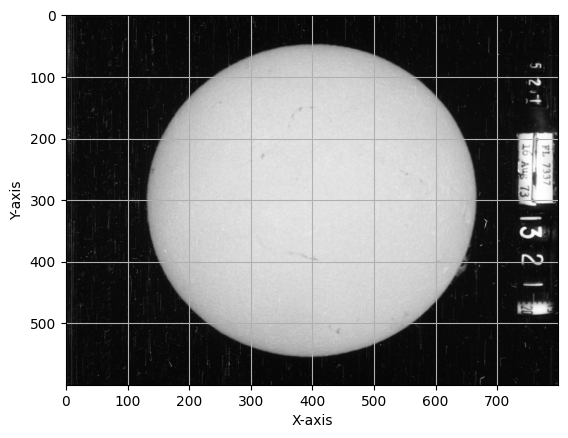

In [4]:
# %%
import os
# 设置环境变量解决OpenMP冲突
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
from PIL import Image  # 确保在所有函数之前导入PIL

# 自定义函数：转换为jpg文件
def fts_to_jpg(image_fts):
    min_val = np.min(image_fts)
    max_val = np.max(image_fts)
    if max_val == min_val:
        # 防止除零错误，返回全零数组（也可改为全255，根据实际需求）
        normalized_array = np.zeros_like(image_fts)
    else:
        normalized_array = (image_fts - min_val) / (max_val - min_val)
    jpg_scaled_array = normalized_array * 255
    jpg_converted_array = jpg_scaled_array.astype(np.uint8)
    return jpg_converted_array

# 调整图片大小（使用固定尺寸resize，保证输出尺寸一致）
def resize_with_aspect_ratio(data, target_size=(800, 600)):
    img = Image.fromarray(data)
    # 直接使用resize保证得到固定尺寸
    #img_resized = img.resize(target_size, Image.ANTIALIAS)
    img_resized = img.resize(target_size, Image.LANCZOS)
    return np.array(img_resized)

# %%
import cv2
import gzip
import shutil
import glob
from astropy.io import fits

# 设置主目录及输出目录
top_dir = 'E:/pythonfile/main-task-image/'
output_dir = 'E:/pythonfile/main-task/output-fts/'

# 如果输出目录不存在，则创建
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 初始化列表来存储 fts 文件处理后的图像数据
fts_gz_files = []
# 同时保存图像文件名（可用于后续标注匹配）
image_filenames = []

# 遍历主目录下的所有文件和子目录，处理 .fts.gz 文件
for root, dirs, files in os.walk(top_dir):
    for file in files:
        file_path = os.path.join(root, file)
        if file.endswith('.fts.gz'):
            try:
                # 构建解压后存放的 fits 文件路径
                extracted_fits_file = os.path.join(output_dir, file.replace('.gz', ''))
                with gzip.open(file_path, 'rb') as f_in:
                    with open(extracted_fits_file, 'wb') as f_out:
                        shutil.copyfileobj(f_in, f_out)
                hdul = fits.open(extracted_fits_file)
                data = hdul[0].data
                hdul.close()
                # 对图像数据进行上下翻转
                data = np.flipud(data)
                # 转换为jpg格式并调整尺寸
                data = fts_to_jpg(data)
                data = resize_with_aspect_ratio(data, target_size=(800, 600))
                fts_gz_files.append(data)
                # 保存对应的文件名称（去除路径、扩展名），便于后续匹配XML文件
                image_filenames.append(os.path.splitext(os.path.basename(file))[0])
            except Exception as e:
                print(f"读取文件 {file_path} 时出错: {e}")

# 展示一幅图像进行检查（根据实际索引选择）
import matplotlib.pyplot as plt
if len(fts_gz_files) > 1:
    plt.imshow(fts_gz_files[1], cmap='gray')
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.show()
else:
    print("未找到足够的图像数据进行展示。")


In [5]:

# %%
# 修改数据集部分，适配YOLOv8格式
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# YOLO格式的数据集定义：通过XML文件与图像进行匹配
class YOLODataset(Dataset):
    def __init__(self, fts_gz_files, xml_dir, transform=None, label_mapping=None):
        """
        fts_gz_files: 图像数据列表
        xml_dir: 存放所有 XML 文件的目录
        transform: 图像预处理转换
        label_mapping: 标注标签映射字典
        """
        self.fts_gz_files = fts_gz_files
        self.transform = transform
        self.label_mapping = label_mapping or {'text': 1}
        
        # 获取并排序 XML 文件列表
        xml_files = sorted(glob.glob(os.path.join(xml_dir, "*.xml")))
        if len(xml_files) != len(self.fts_gz_files):
            raise ValueError(f"图像数 ({len(self.fts_gz_files)}) 与 XML 文件数 ({len(xml_files)}) 不一致！")
        
        # 构建文件名到XML映射（这里假设XML的文件名中含有图像名称，可以根据实际调整）
        self.annotation_map = {}
        for xml_file in xml_files:
            filename = os.path.splitext(os.path.basename(xml_file))[0]
            self.annotation_map[filename] = xml_file
        
        # 遍历图像列表，并加载对应的XML标注
        self.annotations = []
        # 固定图像尺寸，需要与图像预处理一致（此处均为 800×600）
        width = 768
        height = 600
        
        for xml_file in xml_files:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            boxes = []
            labels = []
            
            for obj in root.findall('object'):
                label = obj.find('name').text
                class_id = self.label_mapping.get(label, 0)
                bnd = obj.find('bndbox')
                xmin = float(bnd.find('xmin').text)
                ymin = float(bnd.find('ymin').text)
                xmax = float(bnd.find('xmax').text)
                ymax = float(bnd.find('ymax').text)
                
                # 转换为 YOLO 格式 (x_center, y_center, width, height) 归一化处理
                x_center = ((xmin + xmax) / 2) / width
                y_center = ((ymin + ymax) / 2) / height
                box_width = (xmax - xmin) / width
                box_height = (ymax - ymin) / height
                
                boxes.append([x_center, y_center, box_width, box_height])
                labels.append(class_id)
            
            self.annotations.append({
                'boxes': np.array(boxes, dtype=np.float32),
                'labels': np.array(labels, dtype=np.int64)
            })
    
    def __len__(self):
        return len(self.fts_gz_files)
    
    def __getitem__(self, idx):
        # 获取图像
        image = self.fts_gz_files[idx]
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)
        
        # 应用预处理
        if self.transform:
            image = self.transform(image)
        
        # 获取标注信息
        annotation = self.annotations[idx]
        boxes = annotation['boxes']
        labels = annotation['labels']
        
        return image, boxes, labels


In [6]:

# 定义数据预处理（统一使用 800×600 尺寸，与XML中归一化基准一致）
transform = transforms.Compose([
    transforms.Resize((600, 768)),
    transforms.ToTensor(),
])

# 类别映射，根据实际类别修改
label_mapping = {
    'background': 0,
    'filter': 1,
    'rell_number': 2,
    'date': 3,
    'hour': 4,
    'minute': 5,
    'seconds': 6
}

# XML 文件目录（请根据实际路径调整）
xml_dir = "E:/pythonfile/main-task/image_split/temp_output"
dataset = YOLODataset(
    fts_gz_files=fts_gz_files,
    xml_dir=xml_dir,
    transform=transform,
    label_mapping=label_mapping
)

# 数据集拆分：70%训练，15%验证，剩余作为测试
num_total = len(dataset)
train_size = int(0.7 * num_total)
val_size = int(0.15 * num_total)
test_size = num_total - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])



In [7]:

# 准备临时目录来保存YOLO格式数据集
import tempfile
from pathlib import Path

def create_yolo_dataset(dataset, output_dir, prefix):
    images_dir = os.path.join(output_dir, 'images', prefix)
    labels_dir = os.path.join(output_dir, 'labels', prefix)
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    
    for i, (image, boxes, labels) in enumerate(dataset):
        # 保存图像
        img_path = os.path.join(images_dir, f'{i}.jpg')
        # image 已经是Tensor，转换回 PIL 图片保存
        img = transforms.ToPILImage()(image)
        img.save(img_path)
        
        # 保存标注文本文件：YOLO格式（class x_center y_center width height）
        label_path = os.path.join(labels_dir, f'{i}.txt')
        with open(label_path, 'w') as f:
            for box, label in zip(boxes, labels):
                f.write(f"{label} {box[0]} {box[1]} {box[2]} {box[3]}\n")


In [8]:

# 创建临时数据集目录
temp_dir = tempfile.mkdtemp()
print(f"临时数据集目录: {temp_dir}")

# 准备训练、验证及测试数据集（图像和标注）
create_yolo_dataset(train_dataset, temp_dir, 'train')
create_yolo_dataset(val_dataset, temp_dir, 'val')
create_yolo_dataset(test_dataset, temp_dir, 'test')

# 创建数据集YAML文件（注意 paths 与预处理后的目录对应）
yaml_content = f"""
path: {temp_dir}
train: images/train
val: images/val
test: images/test

nc: {len(label_mapping)}
names: {list(label_mapping.keys())}
"""
yaml_path = os.path.join(temp_dir, 'dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)


临时数据集目录: C:\Users\kuinan\AppData\Local\Temp\tmpqv2k1ozn


In [9]:
import torch
# 依赖 ultralytics 的 YOLO
from ultralytics import YOLO


In [10]:

# GPU检查
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")
# %%
# 加载YOLOv8n模型 (轻量级，适合RTX 1650)，并传入对应权重文件（请确保权重文件存在）
model = YOLO('yolov8n.pt')


Using GPU: GeForce GTX 1650


In [ ]:
results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640, 
    batch=8, 
    device=0,       # 使用第一个GPU（若无GPU则自动切换为CPU）
    patience=5,
    save=True,
    project='yolo_train_results'
)


Ultralytics 8.3.107  Python-3.8.17 torch-2.4.1+cu118 CUDA:0 (GeForce GTX 1650, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\dataset.yaml, epochs=10, time=None, patience=5, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=yolo_train_results, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=Tru

train: Scanning C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\labels\train... 1033 images, 46 backgrounds, 0 corrupt: 100%|██████████| 1033/1033 [00:01<00:00, 925.91it/s]


train: New cache created: C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\labels\train.cache


val: Scanning C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\labels\val... 221 images, 9 backgrounds, 0 corrupt: 100%|██████████| 221/221 [00:00<00:00, 600.28it/s]


val: New cache created: C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\labels\val.cache
Plotting labels to yolo_train_results\train6\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000909, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to yolo_train_results\train6
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      10/10      2.15G      1.156     0.7444     0.9877          6        640: 100%|██████████| 130/130 [00:36<00:00,  3.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:03<00:00,  4.14it/s]

                   all        221       1179      0.985       0.99      0.991       0.67



10 epochs completed in 0.135 hours.
Optimizer stripped from yolo_train_results\train6\weights\last.pt, 6.2MB
Optimizer stripped from yolo_train_results\train6\weights\best.pt, 6.2MB

Validating yolo_train_results\train6\weights\best.pt...
Ultralytics 8.3.107  Python-3.8.17 torch-2.4.1+cu118 CUDA:0 (GeForce GTX 1650, 4096MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:05<00:00,  2.62it/s]


                   all        221       1179      0.985       0.99      0.991      0.671
                filter        127        127      0.989      0.992      0.988      0.633
           rell_number        210        210      0.981      0.981      0.988      0.693
                  date        209        209      0.981      0.984      0.993      0.668
                  hour        211        211      0.989          1      0.994        0.7
                minute        212        212      0.984      0.991      0.994      0.758
               seconds        210        210      0.984      0.995      0.989      0.573
Speed: 0.4ms preprocess, 6.1ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to yolo_train_results\train6


In [47]:

# %%
# 模型验证
val_results = model.val()


Ultralytics 8.3.107  Python-3.8.17 torch-2.4.1+cu118 CUDA:0 (GeForce GTX 1650, 4096MiB)


Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\labels\val.cache... 221 images, 9 backgrounds, 0 corrupt: 100%|██████████| 221/221 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 28/28 [00:04<00:00,  6.09it/s]


                   all        221       1179      0.985       0.99      0.991      0.671
                filter        127        127      0.989      0.992      0.988      0.633
           rell_number        210        210      0.981      0.981      0.988      0.693
                  date        209        209      0.981      0.984      0.993      0.668
                  hour        211        211      0.989          1      0.994        0.7
                minute        212        212      0.984      0.991      0.994      0.758
               seconds        210        210      0.984      0.995      0.989      0.573
Speed: 0.5ms preprocess, 6.6ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to yolo_train_results\train62


In [51]:

# 在测试集上测试
test_results = model.predict(source=os.path.join(temp_dir, 'images/test'),
    conf=0.25,
    save=True,
    project='yolo_prediction_results',
    name='testzhijie')
print("测试完成，预测结果已保存")

# 如不再需要，可以清理临时目录
# import shutil
# shutil.rmtree(temp_dir)



image 1/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\0.jpg: 512x640 1 filter, 1 rell_number, 1 date, 1 hour, 1 minute, 1 seconds, 28.2ms
image 2/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\1.jpg: 512x640 1 filter, 1 rell_number, 1 date, 1 hour, 1 minute, 1 seconds, 24.7ms
image 3/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\10.jpg: 512x640 1 rell_number, 1 date, 1 hour, 1 minute, 1 seconds, 18.1ms
image 4/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\100.jpg: 512x640 1 rell_number, 1 date, 1 hour, 1 minute, 1 seconds, 23.4ms
image 5/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\101.jpg: 512x640 1 filter, 1 rell_number, 1 date, 1 hour, 1 minute, 1 seconds, 15.0ms
image 6/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\102.jpg: 512x640 1 filter, 1 rell_number, 1 date, 1 hour, 1 minute, 1 seconds, 14.0ms
image 7/222 C:\Users\kuinan\AppData\Local\Temp\tmph8ff_v67\images\test\103.jpg: 51

In [ ]:
# 1. 加载训练好的最佳模型
best_model = YOLO('yolo_train_results/train6/weights/best.pt')

# 2. 在验证集上进行详细验证评估
print("\n>> val data evaluation:")#验证集评估
metrics_summary = best_model.val(
    data=yaml_path,
    split='val',
    verbose=True,
    conf=0.25,
    iou=0.5,
    plots=True
)

# 正确处理数组类型的评估指标
print(f"val data mAP@0.5: {metrics_summary.box.map50:.4f}")#验证集
print(f"val data mAP@0.5:0.95: {metrics_summary.box.map:.4f}")#验证集

# 对于可能是数组的指标，使用平均值或首个值
if hasattr(metrics_summary.box, 'p'):
    if isinstance(metrics_summary.box.p, np.ndarray):
        print(f"(Precision): {np.mean(metrics_summary.box.p):.4f} ")#验证集精确率(平均值)
    else:
        print(f"(Precision): {metrics_summary.box.p:.4f}")#验证集精确率
        

if hasattr(metrics_summary.box, 'r'):
    if isinstance(metrics_summary.box.r, np.ndarray):
        print(f"(Recall): {np.mean(metrics_summary.box.r):.4f} ")#验证集召回率(平均值)
    else:
        print(f"(Recall): {metrics_summary.box.r:.4f}")#验证集召回率

# 显示每个类别的性能
print("\n>>Analysis by category :")#各类别性能分析
for i, class_name in enumerate(label_mapping.keys()):
    if i == 0:  # 跳过背景类别
        continue
    try:
        # 检查是否为数组并且长度足够
        if isinstance(metrics_summary.box.p, np.ndarray) and len(metrics_summary.box.p) > i-1:
            class_p = metrics_summary.box.p[i-1]
        else:
            class_p = float('nan')
            
        if isinstance(metrics_summary.box.r, np.ndarray) and len(metrics_summary.box.r) > i-1:
            class_r = metrics_summary.box.r[i-1]
        else:
            class_r = float('nan')
            
        print(f" category'{class_name}': Precision={class_p:.4f}, Recall={class_r:.4f}")#类别
    except (IndexError, AttributeError) as e:
        print(f"无法获取类别 '{class_name}' 的性能数据: {e}")


print("\n>> test data evaluation:")#测试集评估
test_results = best_model.predict(
    source=os.path.join(temp_dir, 'images/test'),
    conf=0.25,
    save=True,
    project='yolo_prediction_results',
    name='test'
)
# 打印预测数量等基本信息
print(f"test images data number: {len(test_results)}")#测试集图像数量
print(f"test data prediction result in: yolo_prediction_results/test/")#预测结果已保存至

# 4. 模型导出
#print("\n>> 导出模型:")
#best_model.export(format='onnx')
#print(f"模型已导出为ONNX格式，保存在 'yolo_train_results/train/weights/' 目录下")



>> val data evaluation:
Ultralytics 8.3.107  Python-3.8.17 torch-2.4.1+cu118 CUDA:0 (GeForce GTX 1650, 4096MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning C:\Users\kuinan\AppData\Local\Temp\tmpqv2k1ozn\labels\val.cache... 221 images, 5 backgrounds, 0 corrupt: 100%|██████████| 221/221 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:03<00:00,  4.20it/s]


                   all        221       1197      0.989       0.99      0.989        0.7
                filter        122        122      0.992      0.992      0.992      0.667
           rell_number        216        216      0.991       0.99      0.992        0.7
                  date        215        215      0.977      0.977      0.972      0.688
                  hour        215        215      0.995      0.995      0.994      0.732
                minute        216        216      0.984      0.991      0.992      0.784
               seconds        213        213      0.995      0.995      0.992      0.627
Speed: 0.6ms preprocess, 6.0ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\detect\val6
val data mAP@0.5: 0.9891
val data mAP@0.5:0.95: 0.6997
(Precision): 0.9890 (平均值)
(Recall): 0.9898 (平均值)

>>Analysis by category :
 category'filter': Precision=0.9918, Recall=0.9918
 category'rell_number': Precision=0.9907, Recall=0.9899
 category'date': Precisi